<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
<a id="install"></a>
<h3 style="font-weight:bold; color:red;">Install Qiskit</h3>

First, check that the version of Python you are using in your environment is python>=3.10, to make sure that it is compatible with the latest Qiskit version we will use:

In [1]:
from platform import python_version

print(python_version())

3.11.8


<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
If that is not the case, you can upgrade it using your preferred tool. If you are unsure how to do it, some recommended options are:

- MacOS: [Homebrew (Click Here)](https://brew.sh/)
- Linux: `sudo apt-get update `

A detailed guide on how to upgrade Python depending on your OS is detailed here: [How to update Python (Click Here)](https://4geeks.com/how-to/how-to-update-python-version)

<div style="
background:linear-gradient(90deg,#0f2027,#203a43,#2c5364);
padding:14px;
border-radius:10px;
margin-top:10px;
">

<h1 style="color:white;margin:0;font-family:Times New Roman;">
📖 Chapter 1 | Theoretical Overview 
</h1>

</div>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">

<p style="font-size:17px;">
The <strong style="color:blue">Variational Quantum Eigensolver (VQE)</strong> is a hybrid quantum–classical algorithm used to estimate the <b>lowest eigenvalue</b> of a Hamiltonian.
In many practical problems, this corresponds to finding the <b>ground state energy</b> of a quantum system.
</p>

<p style="font-size:17px;">
VQE is one of the most important algorithms for the <b>NISQ (Noisy Intermediate-Scale Quantum)</b> era because it uses <b>relatively shallow quantum circuits</b>. This makes it more practical than algorithms such as <strong style="color:blue">Quantum Phase Estimation (QPE)</strong>, which require long coherent circuits that are difficult to run on current noisy hardware.
</p>

<h3 style="font-weight:bold; color:green;">Basic Idea</h3>

<p style="font-size:17px;">
The VQE algorithm relies on the <b>variational principle</b>, which states that for any trial quantum state <b>
\[|\psi(\theta)\rangle : \langle \psi (\theta)| \hat{H} | \psi (\theta)\rangle \geq E_0 \]

<div>
<p style="font-size:17px;">
where <b>E_0</b> is the true ground state energy of the Hamiltonian.
</p>

<p style="font-size:17px;">
Therefore, by minimizing the expectation value, we can approximate the ground state energy of the system. 
\[E(\theta) = \langle \psi (\theta)| \hat{H} | \psi (\theta)\rangle\]

<div>
<details style="cursor: pointer; padding: 10px; ">
        <summary style="font-size:14px; font-weight: bold; color: blue;">Mathematical Insight of Variational Principle</summary>
<p style="font-size:17px;">
<p style="font-size:17px;">
The eigenstates of a Hamiltonian form a complete basis of the Hilbert space: 
\[|\psi_0\rangle, |\psi_1\rangle, |\psi_2\rangle,\dots , |\psi_n\rangle\]
<div>

<p style="font-size:17px;">
Therefore any trial state can be expressed as a linear combination of these eigenstates: 
\[|\psi_{var} \rangle = \sum c_i |\psi_i\rangle\]
<div>
<p style="font-size:17px;">
with the normalization condition:  
\[\sum |c_i|^2 = 1\]
<div>

<p style="font-size:17px;">
Because of this expansion, the expectation value of the Hamiltonian for any trial state must always be greater than or equal to the ground state energy.
</p>

</details>

<h3 style="font-weight:bold; color:green;">Main Components of VQE</h3>

<p style="font-size:17px;">
A VQE calculation involves four essential components: 1. Hamiltonian, 2. Ansatz, 3. Estimator & 4. Optimizer
</p>
</div>

<div style="text-align:center;margin-top:15px;margin-bottom:15px;">
<img src="https://aipp.silverchair-cdn.com/aipp/content_public/journal/jcp/159/4/10.1063_5.0161057/1/044117_1_5.0161057.figures.online.f1.jpeg"
width="70%" style="item-align:center;">

<p style="text-align:center;font-size:15px;color:#555;">
Schematic representation of the VQE hybrid quantum–classical optimization loop
</p>
</div>
<h4 style="color:blue;font-weight:bold">Hybrid Quantum–Classical Loop</h4>

<p style="font-size:17px;">
VQE combines quantum state preparation with classical optimization. The algorithm proceeds iteratively:
</p>

<ol style="font-size:17px; margin-left:30px">
<li>1. Choose a parameterized quantum circuit (ansatz).</li>
<li>2. Prepare the quantum state <b>|ψ⟩</b> on a quantum computer.</li>
<li>3. Measure expectation values of the Hamiltonian.</li>
<li>4. Compute the energy <b>E(θ)</b>.</li>
<li>5. A classical optimizer updates the parameters <b>θ</b>.</li>
<li>6. Repeat until the energy converges.</li>
</ol>

<p style="font-size:17px;">
The final energy approximates the <b>ground state energy</b>, and the corresponding circuit parameters define an approximation of the ground state.
</p>


</div>

<div style="
background:linear-gradient(90deg,#42275a,#734b6d);
padding:12px 20px;
border-radius:8px;
margin-top:10px;
margin-bottom:10px;">

<h2 style="
color:white;
margin:0;
font-family:Times New Roman;">
💻 Chapter 2 | Hands-on VQE Workshop
</h2>

</div>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<a id="index"></a>
<p style="font-size:17px;">
In this section we will implement the <b>Variational Quantum Eigensolver (VQE)</b>
algorithm using <b>Qiskit</b>. The goal is to approximate the 
<b>ground state energy</b> of different physical systems by minimizing the
expectation value of the Hamiltonian.
</p>

<p style="text-align:center;font-size:19px;margin-top:12px;">
\[E_{g.s} = \min_{\theta} \langle \psi(\theta) | H | \psi(\theta) \rangle\]

<div>
<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h3 style="color:red; font-weight:bold">Coding Roadmap</h3>

<p style="font-size:17px;">
In this hands-on session we will implement the <b>Variational Quantum Eigensolver (VQE)</b> step by step.  
The workflow starts with installation and setup, followed by ground state simulation of the <b>Ising model</b>, and finally a <b>quantum chemistry example (H₂ molecule)</b>.
</p>

<ul style="font-size:17px;">

<li>
<b><a href="#setup"> Installation and Imports</a></b>  <br>
Install required libraries and import Qiskit modules.
</li>

<li>
<b style="color:green">Part A — VQE for Ising Model</b>
<ul>

<li><a href="#ising-hamiltonian">1.1 Defining the Ising Hamiltonian</a></li>

<li><a href="#ising-ansatz">1.2 Designing the Ansatz</a></li>

<li><a href="#ising-statevector">1.3 VQE with StatevectorEstimator for Ising Hamiltonian</a></li>

<li><a href="#ising-aer">1.4 VQE with Aer Noise Model for Ising Hamiltonian</a></li>

<li><a href="#ising-fake">1.5 VQE on Backends for Ising Hamiltonian</a></li>

</ul>
</li>

<li>
<b style="color:green">Part B — VQE for H₂ Molecule</b>
<ul>

<li><a href="#h2-hamiltonian">2.1 Constructing Molecular Hamiltonian</a></li>

<li><a href="#h2-ansatz">2.2 Ansatz for Molecular System</a></li>

<li><a href="#h2-statevector">2.3 VQE with StatevectorEstimator for H₂</a></li>

<li><a href="#h2-aer">2.4 VQE with Aer Noise Model for H₂</a></li>

<li><a href="#h2-fake">2.5 VQE on FakeBackends for H₂</a></li>


</ul>
</li>

<li>
<b style="color:green">Part C — Real Quantum Hardware Execution and Benchmarking</b>
<ul>

<li><a href="#qpu_execution">3.1 Running on Real Quantum Computer</a></li>

<li><a href="#ising-compare">3.2 Comparisons over different parameters</a></li>

</ul>
</li>

</ul>

<details>
<summary style="font-size:16px;color:purple;cursor:pointer;font-weight:bold;">
⭐ Learning Goals
</summary>

<ul style="font-size:16px;">
<li>Construct Hamiltonians for physical systems</li>
<li>Design parameterized quantum circuits (ansatz)</li>
<li>Use Qiskit Estimator primitives</li>
<li>Run VQE on ideal and noisy simulators</li>
<li>Simulate molecular ground state energies</li>
</ul>

</details>


<a id="setup"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">Installation and Imports
</h2> 

Run the below code to install required packages

In [2]:
!pip install qiskit qiskit_aer qiskit_algorithms qiskit_ibm_runtime pylatexenc qiskit_nature -q

In [9]:
# Import the required modules
import qiskit
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.optimizers import SPSA, COBYLA, L_BFGS_B, SLSQP, POWELL
from scipy.optimize import minimize
from qiskit_algorithms import NumPyEigensolver
from qiskit.circuit.library import TwoLocal, efficient_su2, n_local, real_amplitudes
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit import transpiler
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from qiskit_algorithms.optimizers import L_BFGS_B # Reverted import
from qiskit_algorithms import VQE # Reverted import
from qiskit.primitives import StatevectorEstimator # Changed from Estimator
import matplotlib.pyplot as plt

<hr style="border:1px solid #cfe0ff;margin:15px 0;">
<h2 style="text-align:center;color:red; font-weight:bold;font-family:'Times New Roman', Times, serif;">PART A | VQE for ISING MODEL</h2>
<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<a id="ising-hamiltonian"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.1 Defining the Ising Hamiltonian
</h2> 
<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:17px;">
The <b>Ising model</b> is one of the simplest models used to study interacting
spin systems in statistical and condensed matter physics. In quantum
computing, it is often used as a benchmark problem for variational algorithms.
</p>

<p style="font-size:17px;">
A general Ising Hamiltonian for <b>n</b> spins can be written as
</p>
\[{\Large H = ∑_{i,j} J_{ij}Z_iZ_j + ∑_i h_iX_i \Large}\]
<div>
<p style="font-size:17px;">
where
</p>

<ul style="font-size:17px;">
<li><b>Z<sub>i</sub></b> represents the Pauli-$Z$ operator acting on qubit <i>i</i></li>
<li><b>h<sub>i</sub></b> represents the local magnetic field</li>
<li><b>J<sub>i,j</sub></b> represents the interaction strength between spins</li>
</ul>

<p style="font-size:17px;">
In this tutorial we construct the Ising Hamiltonian using Pauli operators
so that it can be directly evaluated using the VQE algorithm.
</p>

In [4]:
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Exact Ground State Energy</h3>

In [5]:
eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)
#eigen_values = np.linalg.eigh(Hamiltonian)       # we can also use np.linalg for eigenvalue
gs_energy = eigen_values.eigenvalues[0]
print(f"The exact g.s energy is: {gs_energy} ")

The exact g.s energy is: -1.5075557618995354 


<a id="ising-ansatz"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.2 Designing the Ansatz 
</h2> 

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:17px;">
Qiskit provides several built-in <b>parameterized quantum circuits</b> (ansätze)
used in variational algorithms like VQE. These circuits generate trial quantum
states whose parameters are optimized to minimize the energy of a Hamiltonian.
</p>

<ul style="font-size:17px;">
<li><b>EfficientSU2</b> – Hardware-efficient circuit using rotation gates
(<b>RY, RZ</b>) and entangling CNOT layers.</li>

<li><b>RealAmplitudes</b> – Uses only <b>RY rotations</b> with entanglement;
commonly used for optimization problems.</li>

<li><b>TwoLocal</b> – A flexible ansatz where users can choose rotation gates,
entanglement pattern, and repetitions.</li>

<li><b>PauliTwoDesign</b> – Generates circuits that approximate random unitary
operations using Pauli rotations.</li>
</ul>

</div>

In [6]:
ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)
# ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 3, entanglement = 'circular')
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
print(ansatz.decompose())

This circuit has  16 parameters
global phase: (-0.5)*θ[4] - 0.5*θ[5] - 0.5*θ[6] - 0.5*θ[7] - 0.5*θ[12] - 0.5*θ[13] - 0.5*θ[14] - 0.5*θ[15]
     ┌───────────┐┌─────────┐     ┌───────────┐ ┌──────────┐              »
q_0: ┤ R(θ[0],0) ├┤ P(θ[4]) ├──■──┤ R(θ[8],0) ├─┤ P(θ[12]) ├──────────────»
     ├───────────┤├─────────┤┌─┴─┐└───────────┘┌┴──────────┤ ┌──────────┐ »
q_1: ┤ R(θ[1],0) ├┤ P(θ[5]) ├┤ X ├──────■──────┤ R(θ[9],0) ├─┤ P(θ[13]) ├─»
     ├───────────┤├─────────┤└───┘    ┌─┴─┐    └───────────┘┌┴──────────┴┐»
q_2: ┤ R(θ[2],0) ├┤ P(θ[6]) ├─────────┤ X ├──────────■──────┤ R(θ[10],0) ├»
     ├───────────┤├─────────┤         └───┘        ┌─┴─┐    ├────────────┤»
q_3: ┤ R(θ[3],0) ├┤ P(θ[7]) ├──────────────────────┤ X ├────┤ R(θ[11],0) ├»
     └───────────┘└─────────┘                      └───┘    └────────────┘»
«                 
«q_0: ────────────
«                 
«q_1: ────────────
«     ┌──────────┐
«q_2: ┤ P(θ[14]) ├
«     ├──────────┤
«q_3: ┤ P(θ[15]) ├
«     └──────────┘


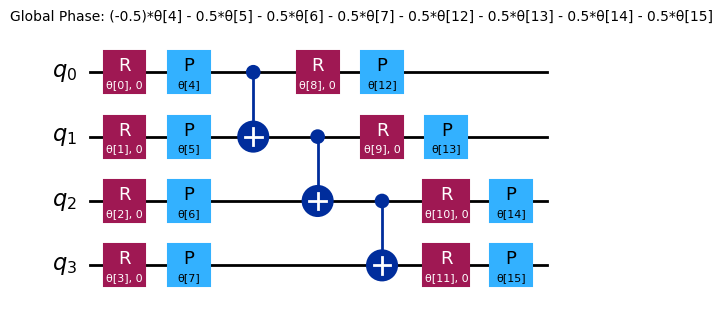

In [7]:
ansatz.decompose().draw('mpl')

<a id="ising-statevector"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.3 VQE with Statevector Estimator for Ising Hamiltonian

</h2> 

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Defining Estimator</h3>

In [8]:
# Use StatevectorEstimator for exact simulation, which is a V2 primitive
# estimator = StatevectorEstimator()
estimator = AerEstimator()

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Estimate the Ground State Energy: 
\[min\langle \psi(\theta)|\hat{H}|\psi(\theta)\rangle\]
<div>


In [9]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """
    Evaluate energy expectation value for given ansatz parameters.

    Parameters
    ----------
    params : ndarray
        Current ansatz parameters θ
    ansatz : QuantumCircuit
        Parameterized quantum circuit
    hamiltonian : SparsePauliOp
        Hamiltonian operator
    estimator : EstimatorV2
        Qiskit estimator primitive

    Returns
    -------
    float
        Estimated expectation value of the Hamiltonian
    """

    # Run estimator
    job = estimator.run([(ansatz, hamiltonian, params)])
    result = job.result()

    energy = float(result[0].data.evs)

    # Store optimization history
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params.copy()
    cost_history_dict["cost_history"].append(energy)

    # Optional logging (cleaner output)
    if cost_history_dict["iters"] % 5 == 0 and LOGGING:
        print(f"Iteration {cost_history_dict['iters']:4d} | Energy = {energy}")

    return energy

In [10]:
# Fix seed for reproducibility
np.random.seed(75)

Maxiter = 200
LOGGING  = True
# Initial guess of parameters
x0 = 2 * np.pi * np.random.random(num_params)

# Dictionary to store optimization history
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

# Run classical optimizer
res = minimize(
    cost_func,
    x0,
    args=(ansatz, Hamiltonian, estimator),
    method="L-BFGS-B",   # You can use other Optimization methods like 'COBYLA', 'Powell', 'Nelder-Mead', 'CG', 'SLSQP'
    options={
        "maxfun": Maxiter,
    },
)

print("\nOptimization Result")
print(res)

Iteration    5 | Energy = -0.2166383980666413
Iteration   10 | Energy = -0.2166384047499523
Iteration   15 | Energy = -0.2166384011353308
Iteration   20 | Energy = -0.9868049218724854
Iteration   25 | Energy = -0.9868049222686736
Iteration   30 | Energy = -0.9868049266212097
Iteration   35 | Energy = 0.08891431623497892
Iteration   40 | Energy = 0.08891431597680324
Iteration   45 | Energy = 0.08891431524940452
Iteration   50 | Energy = 0.08891431627087326
Iteration   55 | Energy = -0.31419714066683674
Iteration   60 | Energy = -0.3141971415497173
Iteration   65 | Energy = -0.3141971394190187
Iteration   70 | Energy = -1.3812816013785207
Iteration   75 | Energy = -1.3812816014333897
Iteration   80 | Energy = -1.3812816020690226
Iteration   85 | Energy = -1.3812816017268283
Iteration   90 | Energy = -1.4623603877729887
Iteration   95 | Energy = -1.4623603869764827
Iteration  100 | Energy = -1.4623603879246176
Iteration  105 | Energy = -1.4986036627532238
Iteration  110 | Energy = -1.4986

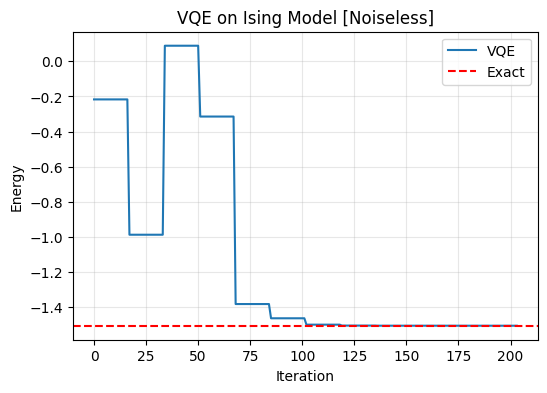

In [11]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(cost_history_dict["cost_history"], label="VQE")
ax.axhline(gs_energy, linestyle="--", color="red", label="Exact")

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title("VQE on Ising Model [Noiseless]")

ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">
Use of VQE pre-build function
</h3>

<p style="font-family:'Times New Roman', Times, serif; font-size:15px;">
The <code>qiskit_algorithms</code> package provides an implementation of the <b>Variational Quantum Eigensolver (VQE)</b>, which allows us to solve eigenvalue problems 
in a much simpler and structured way.
</p>

In [12]:
ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)

counts = []
values = []
params = []
# Running the VQE simulation
def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)

repulsion = 0 # Initializing repulsion variable

vqe = VQE(estimator, 
           ansatz, 
           optimizer=COBYLA(maxiter=250), 
           callback=store_intermediate_result
      )
result = vqe.compute_minimum_eigenvalue(Hamiltonian)

print(result)
print(result.cost_function_evals)
print(result.optimizer_time)


print(f"VQE on Aer qasm simulator (without noise): {result.eigenvalue.real:.15f}")
print(f"Delta from reference energy value is {(result.eigenvalue.real - gs_energy):.5f}")

{   'aux_operators_evaluated': None,
    'cost_function_evals': np.int64(250),
    'eigenvalue': np.float64(-1.5063984424439765),
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x11113ad10>,
    'optimal_parameters': {   ParameterVectorElement(θ[0]): np.float64(6.877831993808633),
                              ParameterVectorElement(θ[1]): np.float64(-3.0821342605939894),
                              ParameterVectorElement(θ[14]): np.float64(1.2968015692125145),
                              ParameterVectorElement(θ[3]): np.float64(-2.9938254292306743),
                              ParameterVectorElement(θ[11]): np.float64(-3.0557741599519583),
                              ParameterVectorElement(θ[15]): np.float64(-0.46926959216615394),
                              ParameterVectorElement(θ[6]): np.float64(-2.30480937393736),
                              ParameterVectorElement(θ[10]): np.float64(3.1038237365697454),
                              Para

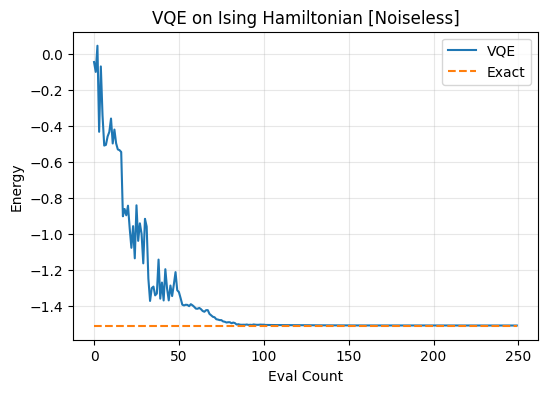

In [13]:
result.optimal_circuit.draw("mpl")
iterations = range(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, np.array(values) + repulsion, label='VQE')
plt.plot(iterations, (gs_energy + repulsion) * np.ones(len(values)), '--', label='Exact')

plt.xlabel("Eval Count")
plt.ylabel('Energy')
plt.title('VQE on Ising Hamiltonian [Noiseless]')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<a id="ising-aer"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.4 VQE with Aer Custom Noise Model for Ising Hamiltonian
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:15px;">
Real quantum hardware is affected by different sources of <b>noise</b> due to imperfect gates, environmental interactions, and measurement errors. To study how algorithms behave in realistic conditions, <b>Qiskit Aer</b> allows us to simulate noisy quantum circuits using configurable <b>noise models</b>.
</p>

<p style="font-size:15px;"><b>Common Noise Sources</b></p>

<ul style="font-size:15px;">
<li><b>Shot Noise</b> : Statistical fluctuations arising from finite measurement samples.</li>
<li><b>Depolarizing Error</b> : The qubit state randomly becomes a maximally mixed state.</li>


<li style="font-size:15px;"><b>Random Pauli Errors</b></li>

<ul style="font-size:15px;">
<li><b>Bit Flip Error</b> → X error (|0⟩ → |1⟩)</li>
<li><b>Phase Flip Error</b> → Z error (phase change)</li>
<li><b>Bit + Phase Flip</b> → Y error</li>
</ul>
</ul>

<p style="font-size:15px;">
A simple depolarizing noise channel can be written as 
\[{\large \rho' = (1-p)\rho + p \frac{I}{4}\large}\]
<div>

<p style="font-size:15px;">
where <b>p</b> represents the probability of error and <b>I</b> is the identity operator. In Qiskit, such noise channels can be implemented using the <code>qiskit_aer.noise</code> module and applied to quantum gates or measurements to emulate realistic quantum hardware behavior.
</p>

</div>

Number of qubits: 4
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
The Exact Ground State Energy is: -1.5075557618995348 
global phase: (-0.5)*θ[4] - 0.5*θ[5] - 0.5*θ[6] - 0.5*θ[7] - 0.5*θ[12] - 0.5*θ[13] - 0.5*θ[14] - 0.5*θ[15] - 0.5*θ[20] - 0.5*θ[21] - 0.5*θ[22] - 0.5*θ[23]
     ┌───────────┐┌─────────┐     ┌───────────┐ ┌──────────┐              »
q_0: ┤ R(θ[0],0) ├┤ P(θ[4]) ├──■──┤ R(θ[8],0) ├─┤ P(θ[12]) ├──────────────»
     ├───────────┤├─────────┤┌─┴─┐└───────────┘┌┴──────────┤ ┌──────────┐ »
q_1: ┤ R(θ[1],0) ├┤ P(θ[5]) ├┤ X ├──────■──────┤ R(θ[9],0) ├─┤ P(θ[13]) ├─»
     ├───────────┤├─────────┤└───┘    ┌─┴─┐    └───────────┘┌┴──────────┴┐»
q_2: ┤ R(θ[2],0) ├┤ P(θ[6]) ├─────────┤ X ├──────────■──────┤ R(θ[10],0) ├»
     ├───────────┤├─────────┤         └───┘        ┌─┴─┐    ├────────────┤»
q_3: ┤ R(θ[3],0) ├┤ P(θ[7]) ├──────────────────────┤ X ├────┤ R(θ[11],0) ├»
     └──

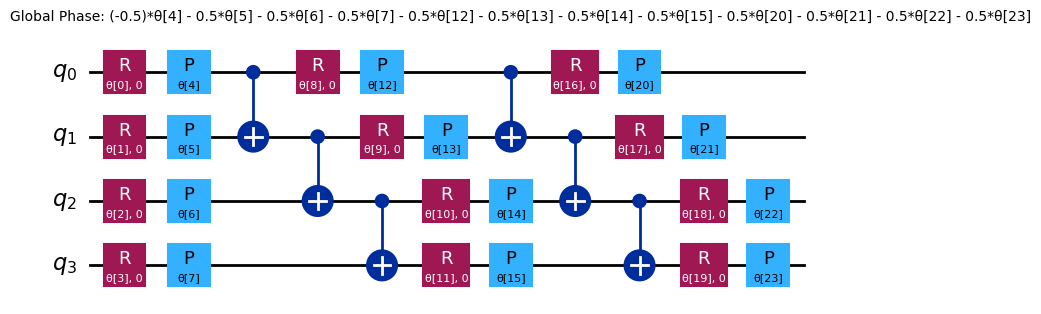

In [21]:
from qiskit_algorithms.utils import algorithm_globals

# Problem Defining 
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])
print(f"Number of qubits: {Hamiltonian.num_qubits}")

# Exact Solution (Exact Eigenvalue)
eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)   # Also can use NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
gs_energy = eigen_values.eigenvalues[0]
print(f"The Exact Ground State Energy is: {gs_energy} ")

iterations = 125

ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 2)
#ansatz = TwoLocal(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)  # Old version 
#ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')

print(ansatz.decompose())
ansatz.decompose().draw("mpl")

In [15]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

seed = 75
algorithm_globals.random_seed = seed

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.01, 1), ["rx", "rz"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.05, 2), ["cx"]
)

print(noise_model)
noisy_estimator = AerEstimator(
    options={
            "backend_options": {"noise_model": noise_model},
            "run_options": {"shots": 4096}
            },
)

# re-start callback variables
counts = []
values = []

vqe.estimator = noisy_estimator
vqe.optimizer = SPSA(maxiter=200)

result_noise = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)

print(f"VQE on Aer qasm simulator (with noise): {result_noise.eigenvalue.real:.5f}")
print(f"Delta from reference energy value is {(result_noise.eigenvalue.real - gs_energy):.5f}")


NoiseModel:
  Basis gates: ['cx', 'id', 'rx', 'rz', 'sx']
  Instructions with noise: ['rz', 'cx', 'rx']
  All-qubits errors: ['rx', 'rz', 'cx']
VQE on Aer qasm simulator (with noise): -1.29960
Delta from reference energy value is 0.20796


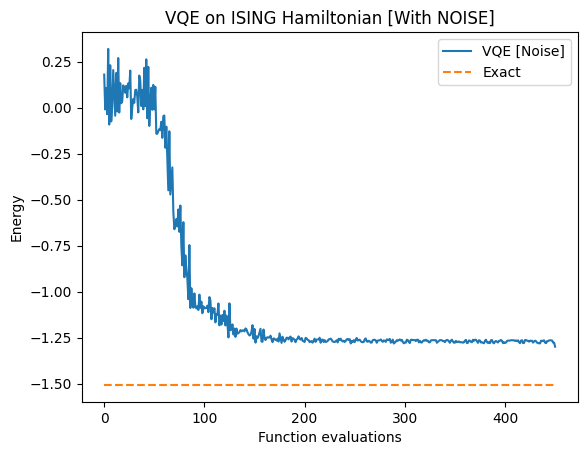

In [16]:
# plot
plt.plot(values)
plt.plot(gs_energy*np.ones(len(values)), '--')
plt.xlabel("Function evaluations")
plt.ylabel('Energy')
plt.legend(['VQE [Noise]', 'Exact'])
plt.title('VQE on ISING Hamiltonian [With NOISE]')
plt.show()

<a id="ising-fake"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.5 VQE on Fake Backend for Ising Hamiltonian
</h2>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
In Qiskit, a <b>FakeBackend</b> is a software model that mimics the behavior of a real IBM Quantum device. Instead of running a circuit on actual quantum hardware, the 
simulation is performed locally on your computer using <b>Qiskit Aer</b>, while still incorporating the hardware properties and noise characteristics of a real device.
</p>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
This allows researchers and students to test and analyze quantum circuits under 
<b>realistic hardware conditions</b> without needing access to an actual quantum computer.
</p>

In [17]:
from qiskit_ibm_runtime.fake_provider import (FakeManilaV2, FakeLimaV2, FakeJakartaV2, FakeAthensV2, FakeBelemV2, 
                                                FakeBogotaV2, FakeCasablancaV2, FakeNairobiV2, FakePerth, FakeOslo)

J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])

eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)
#eigen_values = np.linalg.eigh(Hamiltonian)
gs_energy = eigen_values.eigenvalues[0]
print(f"The Exact Ground State Energy is: {gs_energy} ")

# The ansatz for the VQE
#ansatz = TwoLocal(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')


# Fake backend
backend_choice = "Manila"

backend_map = {
    "Manila": FakeManilaV2,
    "Lima": FakeLimaV2,
    "Jakarta": FakeJakartaV2,
    "Athens": FakeAthensV2,
    "Belem": FakeBelemV2,
    "Bogota": FakeBogotaV2,
    "Casablanca": FakeCasablancaV2,
    "Nairobi": FakeNairobiV2,
    "Perth": FakePerth,
    "Oslo": FakeOslo
}

fake_backend = backend_map[backend_choice]()

# Noise model
noise_model = NoiseModel.from_backend(fake_backend)
print(f"Backend Used: {backend_choice}")
print(noise_model)

# Estimator
fake_estimator = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": fake_backend.coupling_map,
            "basis_gates": fake_backend.operation_names,
        },
        "run_options": {"shots": 4096}}
)

# Transpile ansatz ONCE
# tqc = transpile(ansatz, fake_backend)

# re-start callback variables
counts = []
values = []

vqe.estimator = fake_estimator

result_fake = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)


print(f"VQE on Aer qasm simulator (on FakeBackend): {result_fake.eigenvalue.real:.5f}")
print(f"Delta from reference energy value is {(result_fake.eigenvalue.real - gs_energy):.5f}")


The Exact Ground State Energy is: -1.507555761899536 
Backend Used: Manila
NoiseModel:
  Basis gates: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['id', 'reset', 'sx', 'cx', 'x', 'measure']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
VQE on Aer qasm simulator (on FakeBackend): -1.48014
Delta from reference energy value is 0.02742


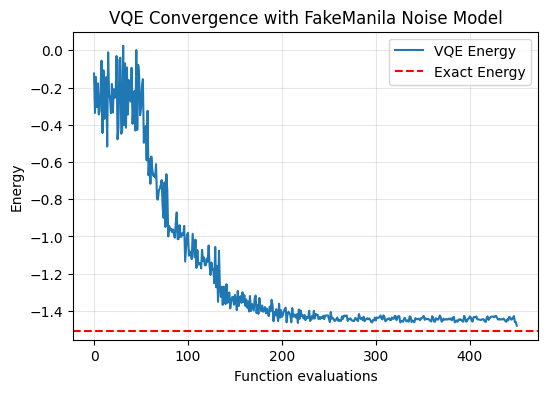

In [18]:
iterations = np.arange(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, values, label="VQE Energy")
plt.axhline(gs_energy, linestyle="--", color="red", label="Exact Energy")

plt.xlabel("Function evaluations")
plt.ylabel("Energy")
plt.title(f"VQE Convergence with Fake{backend_choice} Noise Model")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<a id="setting-ibm-cloud"></a>
<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
<h3 style="font-weight:bold; color:red;">Set up your IBM Cloud account</h3>

We must set up an IBM Cloud account in order to execute quantum circuits on real hardware. First go to [IBM Quantum Platform](https://quantum.cloud.ibm.com/) and Sign in to your existing account or Create an IBM Cloud Account. 


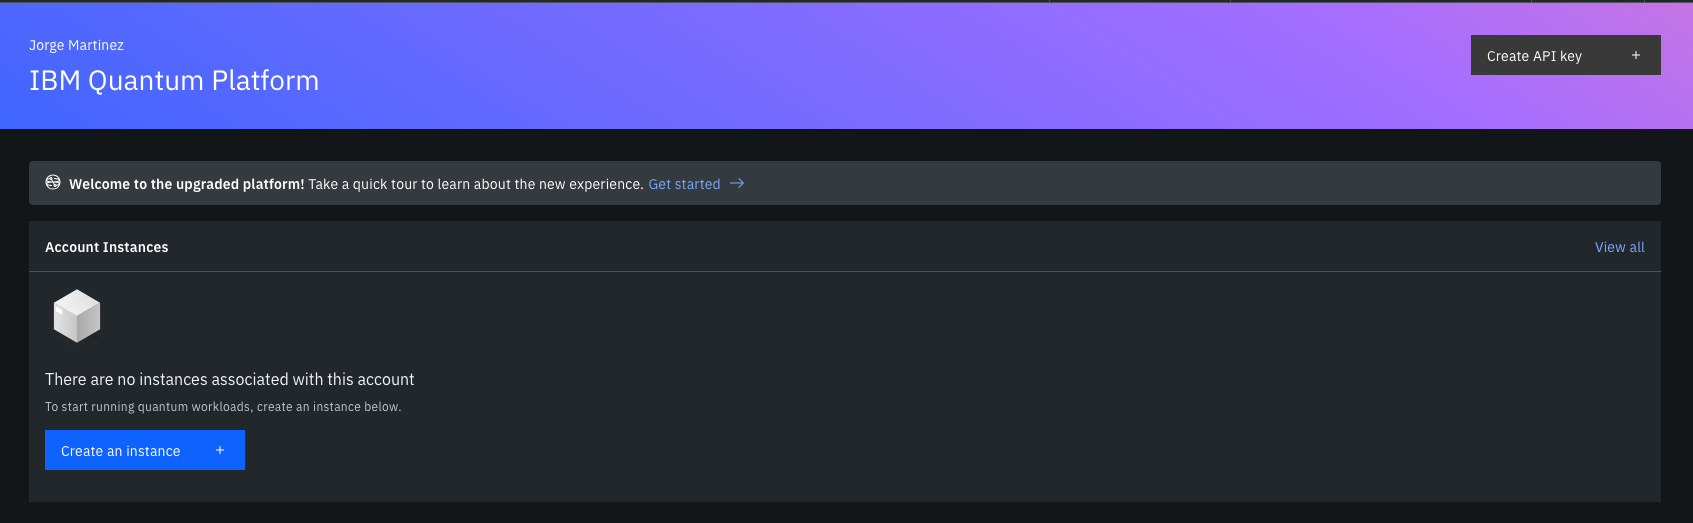



<p>
After logging in, navigate to the <b>Account Settings</b> page and copy your
<b>API Token</b>. This token allows Qiskit to securely connect to your IBM
Quantum account from your local Python environment.
</p>

<p>
Once the API token is obtained, we can save it locally using
<b>Qiskit Runtime</b>. This step only needs to be performed once.
</p>

Number of qubits: 4
The Exact Ground State Energy is: -1.507555761899537 
The Ansatz has 24 parameters.


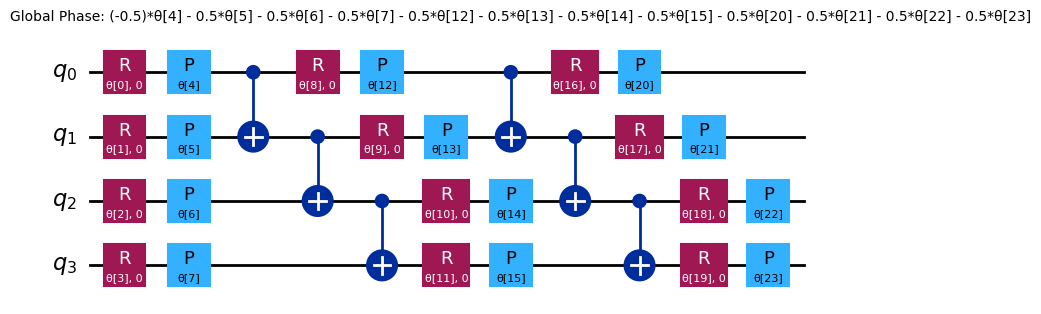

In [17]:
# Problem Defining 
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])
print(f"Number of qubits: {Hamiltonian.num_qubits}")

# Exact Solution (Exact Eigenvalue)
eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)   # Also can use NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
gs_energy = eigen_values.eigenvalues[0]
print(f"The Exact Ground State Energy is: {gs_energy} ")

ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 2)
#ansatz = TwoLocal(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)  # Old version 
#ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')
num_params = ansatz.num_parameters
print(f"The Ansatz has {num_params} parameters.")

ansatz.decompose().draw("mpl")

In [22]:
from qiskit_ibm_runtime import Session, Estimator, QiskitRuntimeService

# Save your API token once
# QiskitRuntimeService.save_account(token="jyqW8iuPXAbQk5W-ho5mpjGXC8jZS8jiO-n2B6YBBB2l", channel='ibm_cloud', overwrite=True, set_as_default=True)
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-04-24 19:08:07,995: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-24 19:08:08,841: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-24 19:08:11,905: Using instance: open-instance, plan: open


ibm_marrakesh


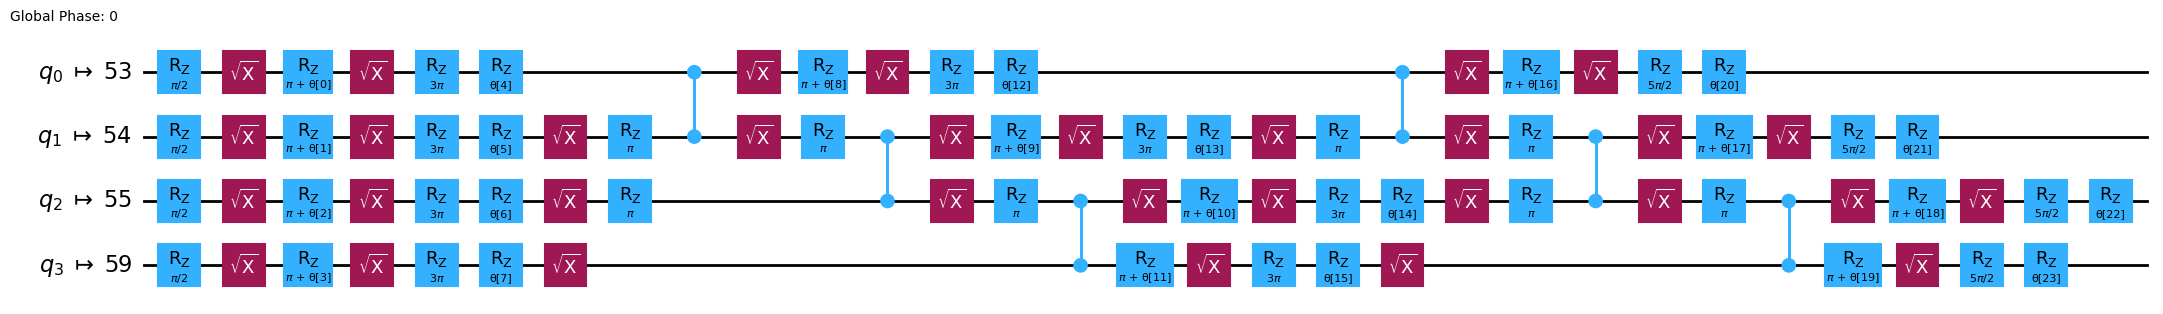

In [23]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = Hamiltonian.apply_layout(layout=ansatz_isa.layout)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp", fold=-1)

In [29]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy


cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
# Initial values of parameters
x0 = 2 * np.pi * np.random.random(num_params)

In [ ]:
estimator = Estimator(mode=backend)
estimator.options.default_shots = 512
res = minimize(cost_func, x0, args=(ansatz_isa, hamiltonian_isa, estimator), method="cobyla", options={"maxiter": 45})

Iters. done: 1 [Current cost: 0.11859414212095817]
Iters. done: 2 [Current cost: -0.13862307616884947]
Iters. done: 3 [Current cost: -0.1690976977215031]
Iters. done: 4 [Current cost: -0.15986747335858564]


In [31]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/567fc31a74814c29a834962b33b17e99:a3e8412b-d325-4eda-909c-a56e5df57b9e::'
)
job = service.job('d7lnkpc3g2mc7391ijgg')
job_result = job.result()

for idx, pub_result in enumerate(job_result):
    print(f"Expectation values for pub {idx}: {pub_result.data.evs}")

Expectation values for pub 0: [-0.78904069]


In [ ]:
final_energy = res.fun + repulsion

print("\nOptimization finished")
print("Optimal parameters:", res.x)
print("Final VQE energy:", final_energy)
print("Exact energy:", gs_energy)
print("Energy error:", abs(final_energy - gs_energy))

In [ ]:
fig, ax = plt.subplots()

# Define the constant function
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.axhline(gs_energy, linestyle="--", color="red", label="Exact")

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title("VQE on Ising Model [Noiseless]")

ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

<hr style="border:1px solid #cfe0ff;margin:15px 0;">
<h2 style="text-align:center;color:red; font-weight:bold;font-family:'Times New Roman', Times, serif;">PART B | VQE for H₂ Molecule</h2>
<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<a id="h2-hamiltonian"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">
2.1 Constructing Molecular Hamiltonian 
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="text-align:right; font-size:17px"><a href="#index">[⬆️ Back to Contents]</a></p>
<p style="font-size:17px;">
One of the most important applications of quantum computing is the simulation of <b>molecular electronic structure</b>. Classical algorithms often struggle with solving the many-body Schrödinger equation for molecules because the size of the Hilbert space grows exponentially with the number of electrons.
</p>

<p style="font-size:17px;">
For a molecular system such as the hydrogen molecule (<b>H₂</b>), the electronic structure problem can be written in the <b>second-quantized form</b> as
</p>

\[H = \sum_{pq} h_{pq} a_p^\dagger a_q
+ \frac{1}{2} \sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s \]
<div>

<p style="font-size:17px;">
where
</p>

<ul style="font-size:16px;">
  <li><b>a<sub>p</sub><sup>&dagger;</sup></b> and <b>a<sub>p</sub></b> are fermionic creation and annihilation operators</li>
  <li><b>h<sub>pq</sub></b> are one-electron integrals describing kinetic energy and nuclear attraction</li>
  <li><b>h<sub>pqrs</sub></b> are two-electron integrals representing electron-electron interactions</li>
</ul>


<p style="font-size:17px;">
To run this Hamiltonian on a quantum computer, the fermionic operators must be mapped to qubit operators. This is typically done using transformations such as the <b>Jordan-Wigner</b> or <b>Bravyi-Kitaev</b> mapping.
After this mapping, the Hamiltonian can be written as a sum of Pauli operators.
</p>

<p style="font-size:17px;">
For the hydrogen molecule in a minimal basis (STO-3G), the qubit Hamiltonian can be expressed as
</p>

<p style="font-size:16px; justify-content:center">
  <b>H</b> = <b>c<sub>0</sub>I</b> + <b>c<sub>1</sub>Z<sub>0</sub></b> + <b>c<sub>2</sub>Z<sub>1</sub></b> + <b>c<sub>3</sub>Z<sub>0</sub>Z<sub>1</sub></b> + <b>c<sub>4</sub>X<sub>0</sub>X<sub>1</sub></b> + <b>c<sub>5</sub>Y<sub>0</sub>Y<sub>1</sub></b>
</p>

<div>

<p style="font-size:17px;">
where the coefficients <b>c<sub>i</sub></b> depend on the inter-nuclear distance of the hydrogen atoms. This Hamiltonian can then be used in the <b>VQE algorithm</b> to approximate the ground state energy of the molecule.
</p>

<p style="font-size:17px;">
In the following sections, we will construct this Hamiltonian using <b>Qiskit Nature</b> and use VQE to estimate the ground state energy of the H₂ molecule.
</p>

</div>

In [19]:
!pip install "qiskit-nature[pyscf]" -q

In [7]:
# Import necessary libraries
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorEstimator # Changed from Estimator
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms import VQE
from qiskit_algorithms.eigensolvers import NumPyEigensolver
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock, UCC

import matplotlib.pyplot as plt
import numpy as np

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Defining Problem</h3>

In [262]:
# Molecular Geometry
driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 0.7")

# The Classical Hamiltonian
problem = driver.run()

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<h4 style="color:blue; font-weight:bold">
What <code style="font-size:15px">PySCFDriver.run()</code> returns?
</h4>

<p style="font-size:17px;">
In <b>Qiskit Nature</b>, molecular electronic structure problems are typically generated using classical quantum chemistry packages such as <b>PySCF</b>. The interface between PySCF and Qiskit Nature is provided by the <code style="font-size:14px">PySCFDriver</code>.
</p>

<p style="font-size:17px;">
When the method <code style="font-size:14px">PySCFDriver.run()</code> is executed, it returns an object of type <code style="font-size:14px">ElectronicStructureProblem</code>. This object acts as a central
container that stores all physically relevant information about the molecular electronic structure problem.
</p>

<p style="font-size:17px;">
The attribute <code style="font-size:14px">problem.hamiltonian</code> is of type <code style="font-size:14px">ElectronicEnergy</code> and represents the electronic Hamiltonian of the molecular system.
</p>

<p style="font-size:17px;">
In first quantization, the electronic Hamiltonian is given by
</p>

\[H_{\text{elec}} = \sum_{i=1}^{N} \left( -\frac{1}{2}\nabla_i^2 - \sum_{A} \frac{Z_A}{|\mathbf{r}_i - \mathbf{R}_A|}\right) + \sum_{i<j}\frac{1}{|\mathbf{r}_i - \mathbf{r}_j|} \]
<div>
<p style="font-size:17px;">
For quantum computing applications, it is more convenient to express this Hamiltonian in <b>second quantization</b>. In this representation the Hamiltonian becomes
</p>

\[H_{\text{elec}} = \sum_{pq} h_{pq} a_p^\dagger a_q + \frac{1}{2}\sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s \]
<div>
<p style="font-size:17px;">
The Hamiltonian above describes only the <b>electronic energy</b>. To obtain the total molecular energy, the <b>nuclear repulsion energy</b> must also be added:
</p>

\[E_{\text{total}} = E_{\text{elec}} + V_{nn}\]
<div>
<p style="font-size:17px;">
At this stage the Hamiltonian is still expressed in terms of <b>fermionic operators</b>. Since quantum computers operate on qubits, the fermionic Hamiltonian must be mapped to a qubit operator using transformations such as the <b>Jordan–Wigner</b> or <b>Bravyi–Kitaev</b> mapping. The resulting qubit Hamiltonian can then be used as input to algorithms such as the <b>Variational Quantum Eigensolver (VQE)</b>.
</p>

</div>

In [329]:
hamiltonian = problem.hamiltonian

# Mapping the Hamiltonian into Qubit Space
second_q_h = hamiltonian.second_q_op()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(second_q_h)
print(hamiltonian_op)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Exact Ground State Energy</h3>

In [330]:
# Nuclear Repulsion Energy
repulsion = hamiltonian.constants.get('nuclear_repulsion_energy')
print("Repulsion Energy : ", repulsion)

Repulsion Energy :  0.7199689944489797


In [331]:
# Exact Energy
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
exact = exact.eigenvalue.real
print("Ground State Energy : ", exact+repulsion)

Ground State Energy :  -1.1373060357533986


<a id="h2-ansatz"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.2 Ansatz for Molecular Systems
</h2> 


In [332]:
ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
# ansatz = UCC(2, (1, 1), excitations='sd', qubit_mapper=JordanWignerMapper(), initial_state=HartreeFock(2,(1,1),JordanWignerMapper()))
# ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')

<a id="h2-statevector"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.3 VQE with Statevector Estimator (Noise Free)  for H₂
</h2> 
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>


In [333]:
# Estimator
estimator = StatevectorEstimator() # Changed from Estimator()

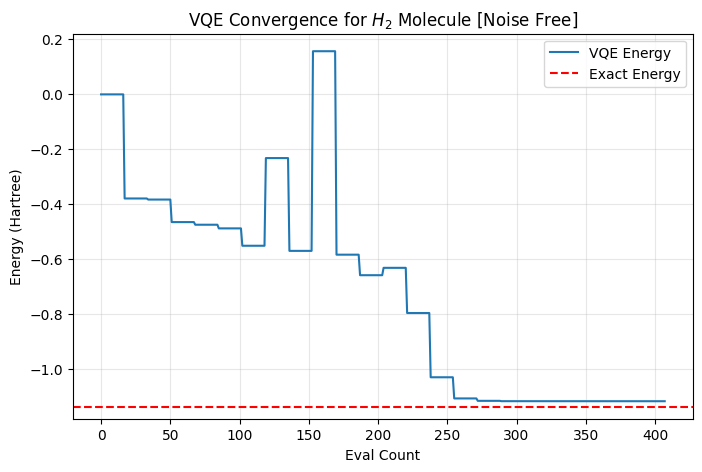

In [ ]:
# Running the VQE simulation

counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator,
    ansatz,
    optimizer=L_BFGS_B(maxiter=200),
    callback=store_intermediate_result
)

result_ideal = vqe.compute_minimum_eigenvalue(hamiltonian_op)

# Convert to total energy by adding nuclear repulsion
vqe_energy = np.array(values) + repulsion
exact_energy = exact + repulsion


# Plotting Results
plt.figure(figsize=(8,5))

plt.plot(range(len(vqe_energy)), vqe_energy, label='VQE Energy')

plt.axhline(exact_energy, linestyle='--', color='red', label='Exact Energy')

plt.xlabel('Eval Count')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for H₂ Molecule [Noise Free]')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<a id="h2-aer"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.4 VQE with Custom Noise Model  for H₂
</h2> 
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>

Ground State Energy :  -1.1373060357533986
Final Energy (with noise): -1.114045 Hartree
ΔE Error (with noise): 0.023261 Hartree


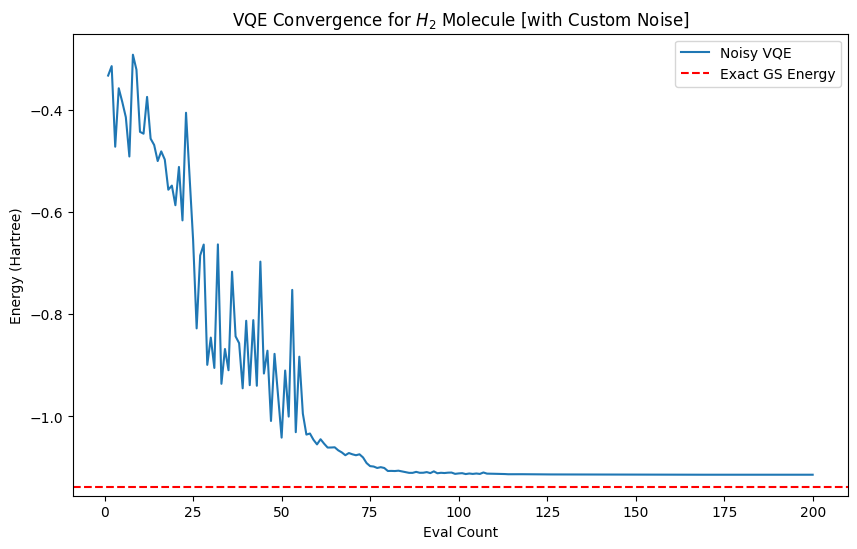

In [ ]:
# 1. Setup Molecule and Hamiltonian
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(problem.hamiltonian.second_q_op())
repulsion = problem.hamiltonian.constants.get('nuclear_repulsion_energy')

# 2. Exact Solution 
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
gs_energy = exact.eigenvalue.real +repulsion
print("Ground State Energy : ", gs_energy)

# 2. Setup Ansatz
ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
# ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')
# ansatz = UCC(num_spatial_orbitals=2, num_particles=(1, 1), excitations='sd', qubit_mapper=mapper, initial_state=HartreeFock(2, (1, 1), mapper) )

ansatz = ansatz.decompose(reps=2)

# 3. Create Noise Model
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.002, 2), ["cx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.001, 1), ["rz", "sx", "x", "ry"])

# 4. Define Estimator
estimator_noise = AerEstimator(options={"backend_options":{"noise_model": noise_model},                                   
                                   "run_options": {"shots": 4096}
                                 }
)

#5. Running VQE 
counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator_noise,
    ansatz,
    optimizer=COBYLA(maxiter=200),
    callback=store_intermediate_result
)

result_noise = vqe.compute_minimum_eigenvalue(hamiltonian_op)
# print(result_noise)

# 6. Final Energy and Plot
final_energy = result_noise.optimal_value + repulsion
print(f"Final Energy (with noise): {final_energy:.6f} Hartree")
print(f"ΔE Error (with noise): {final_energy-gs_energy:.6f} Hartree")

plt.figure(figsize=(10, 6))
plt.plot(counts, np.array(values) + repulsion, label='Noisy VQE')
plt.axhline(y=gs_energy, color='r', linestyle='--', label='Exact GS Energy')
plt.xlabel('Eval Count')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for H₂ Molecule [with Custom Noise]')
plt.legend()
plt.show()

<a id="h2-fake"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.5 VQE on FakeBackend for H₂
</h2> 
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>

Ground State Energy :  -1.1373060357533968
Backend Used: Manila
NoiseModel:
  Basis gates: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['cx', 'reset', 'measure', 'id', 'x', 'sx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Final Energy (with noise): -0.633545 Hartree
ΔE Error (with noise): 0.503761 Hartree


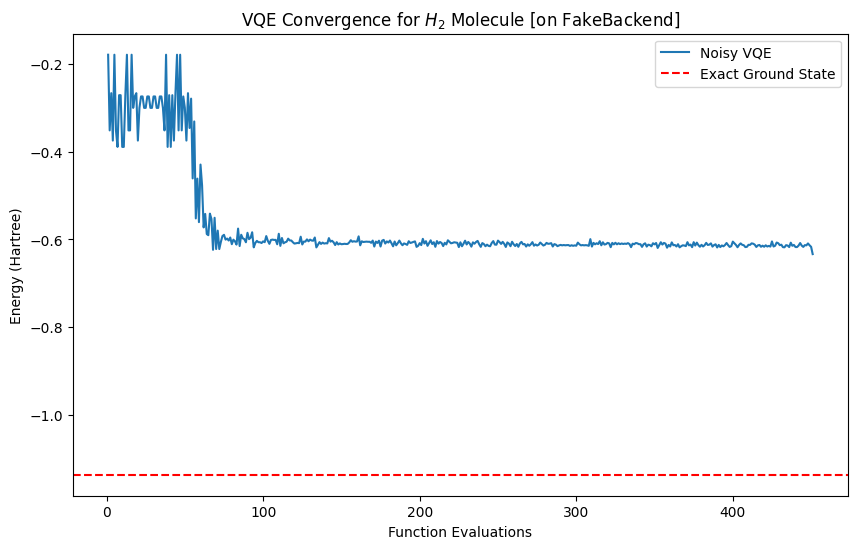

In [ ]:
# 1. Setup Molecule and Hamiltonian
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(problem.hamiltonian.second_q_op())
repulsion = problem.hamiltonian.constants.get('nuclear_repulsion_energy')

# 2. Exact Solution 
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
gs_energy = exact.eigenvalue.real +repulsion
print("Ground State Energy : ", gs_energy)

# 2. Setup Ansatz
# ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
#ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')
ansatz = UCC(num_spatial_orbitals=2, num_particles=(1, 1), excitations='sd', qubit_mapper=mapper, initial_state=HartreeFock(2, (1, 1), mapper) )

ansatz = ansatz.decompose(reps=2)

# 3. Create Noise Model
# Fake backend
backend_choice = "Manila"
backend_map = {
    "Manila": FakeManilaV2,
    "Jakarta": FakeJakartaV2,
    "Nairobi": FakeNairobiV2,
}
fake_backend = backend_map[backend_choice]()
# Noise model
noise_model = NoiseModel.from_backend(fake_backend)
print(f"Backend Used: {backend_choice}")
print(noise_model)

# 4. Define Estimator
estimator_fake = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": fake_backend.coupling_map,
            "basis_gates": fake_backend.operation_names,
        },
        "run_options": {"shots": 4096}}
)


#5. Running VQE 
counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator_fake,
    ansatz,
    optimizer=SPSA(maxiter=200),
    callback=store_intermediate_result
)

result_noise = vqe.compute_minimum_eigenvalue(hamiltonian_op)
# print(result_noise)

# 6. Final Energy and Plot
final_energy = result_noise.optimal_value + repulsion
print(f"Final Energy (with noise): {final_energy:.6f} Hartree")
print(f"ΔE Error (with noise): {final_energy-gs_energy:.6f} Hartree")

plt.figure(figsize=(10, 6))
plt.plot(counts, np.array(values) + repulsion, label='Noisy VQE')
plt.axhline(y=gs_energy, color='r', linestyle='--', label='Exact Ground State')
plt.xlabel('Function Evaluations')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for H₂ Molecule [on FakeBackend]')
plt.legend()
plt.show()

<a id="ising-compare"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">3.1 Comparisons over different parameters
</h2>
<p style="text-align:right;">
<a href="#index">[⬆️ Back to Contents]</a>
</p>


<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">
Comparison over Classical Optimizer
</h3>

In [192]:
import time
from qiskit_algorithms import NumPyMinimumEigensolver

# Problem Defining 
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])
algorithm_globals.random_seed = 75

ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')

gs_energy = NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
print("Exact ground state energy:", gs_energy)

# we will iterate over these different optimizers
optimizers = [COBYLA(maxiter=200), L_BFGS_B(maxiter=200), SLSQP(maxiter=200), SPSA(maxiter=200), ADAM(maxiter=200)]
converge_counts = np.empty([len(optimizers)], dtype=object)
converge_vals = np.empty([len(optimizers)], dtype=object)
times = np.zeros(len(optimizers))

for i, optimizer in enumerate(optimizers):
    print("\rOptimizer: {}        ".format(type(optimizer).__name__), end="")

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    start_time = time.time()
    vqe = VQE(estimator, ansatz, optimizer, callback=store_intermediate_result)
    result = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)
    end_time = time.time()

    times[i] = end_time - start_time
    converge_counts[i] = np.asarray(counts)
    converge_vals[i] = np.asarray(values)

print("\rOptimization complete");

#  ______________________ Comparison Table __________________
print("\nFinal Optimizer Comparison\n")

print("{:<12} {:<15} {:<15} {:<12}".format(
    "Optimizer", "Final Energy", "ΔE Error", "Time (s)"
))
print("-"*60)

for i, optimizer in enumerate(optimizers):

    final_energy = converge_vals[i][-1]
    delta = abs(final_energy - gs_energy)

    print("{:<12} {:<15.8f} {:<15.8f} {:<12.4f}".format(
        type(optimizer).__name__,
        final_energy,
        delta,
        times[i]
    ))

Exact ground state energy: -1.5075557618995359
Optimization complete      

Final Optimizer Comparison

Optimizer    Final Energy    ΔE Error        Time (s)    
------------------------------------------------------------
COBYLA       -1.43848194     0.06907382      4.2777      
L_BFGS_B     -1.43902453     0.06853123      7.5462      
SLSQP        -1.43826345     0.06929231      2.6485      
SPSA         -1.43828829     0.06926747      4.6270      
ADAM         -0.23508535     1.27247041      42.4400     


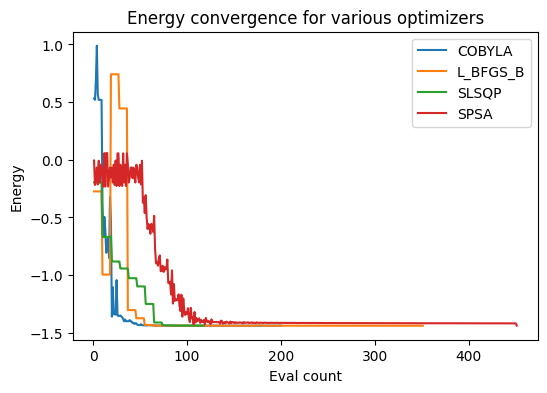

In [194]:
plt.figure(figsize=(6,4))

for i, optimizer in enumerate(optimizers[:-1]):
    plt.plot(converge_counts[i], converge_vals[i], label=type(optimizer).__name__)
plt.axhline(gs_energy, linestyle="--", color="red", label="Exact Energy")
plt.xlabel("Eval count")
plt.ylabel("Energy")
plt.title("Energy convergence for various optimizers")
plt.legend(loc="upper right")
plt.show()

In [205]:
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(
    ['ZZII','IZZI','IIZZ','XIII','IXII','IIXI','IIIX'],
    [J,J,J,h,h,h,h]
)

algorithm_globals.random_seed = 75

gs_energy = NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
print("Exact ground state energy:", gs_energy)

ansatz_list = {
    "EfficientSU2": efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular'),
    "NLocal": n_local(Hamiltonian.num_qubits, rotation_blocks=['ry','rz'], entanglement_blocks='cx', reps=1),
    "RealAmplitudes": real_amplitudes(Hamiltonian.num_qubits, reps=1)
}

optimizers = [COBYLA(maxiter=200), L_BFGS_B(maxiter=200), SPSA(maxiter=200)]

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01,1), ["rx","rz","ry"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05,2), ["cx"])

simulators = {
"noise_free": AerEstimator(options={"run_options": {"shots": 4096}}),
"custom_noise": AerEstimator(options={"backend_options": { "noise_model": noise_model}, "run_options": {"shots": 4096}}),
"fake_jakarta": AerEstimator(options={"backend_options": { "noise_model": NoiseModel.from_backend(FakeJakartaV2()), 
                                                           "coupling_map": fake_backend.coupling_map, "basis_gates": fake_backend.operation_names,},
                                      "run_options": {"shots": 4096}}),
"fake_manila": AerEstimator(options={"backend_options": { "noise_model": NoiseModel.from_backend(FakeManilaV2()), 
                                                           "coupling_map": fake_backend.coupling_map, "basis_gates": fake_backend.operation_names,},
                                      "run_options": {"shots": 4096}})
}

results = []
convergence_data = {}

for ansatz_name, ansatz in ansatz_list.items():
    convergence_data[ansatz_name] = {}
    for sim_type, estimator in simulators.items():
        convergence_data[ansatz_name][sim_type] = {}
        for optimizer in optimizers:
            print( "\rAnsatz: {} | Estimator: {} | Optimizer: {}      ".format( ansatz_name, sim_type, type(optimizer).__name__),end="")
            counts=[]
            values=[]
            def callback(eval_count, parameters, mean, std):
                counts.append(eval_count)
                values.append(mean)
            start=time.time()
            vqe=VQE(estimator, ansatz, optimizer, callback=callback )
            result=vqe.compute_minimum_eigenvalue( operator=Hamiltonian )
            end=time.time()

            final_energy=result.eigenvalue.real
            delta=abs(final_energy-gs_energy)

            convergence_data[ansatz_name][sim_type][type(optimizer).__name__] = {
                "counts": np.array(counts),
                "values": np.array(values)
            }
            
            results.append({
                "Ansatz":ansatz_name,
                "Estimator":sim_type,
                "Optimizer":type(optimizer).__name__,
                "Final Energy":final_energy,
                "ΔE Error":delta,
                "Time (s)":end-start
            })

Exact ground state energy: -1.5075557618995385
Ansatz: RealAmplitudes | Estimator: fake_manila | Optimizer: SPSA           

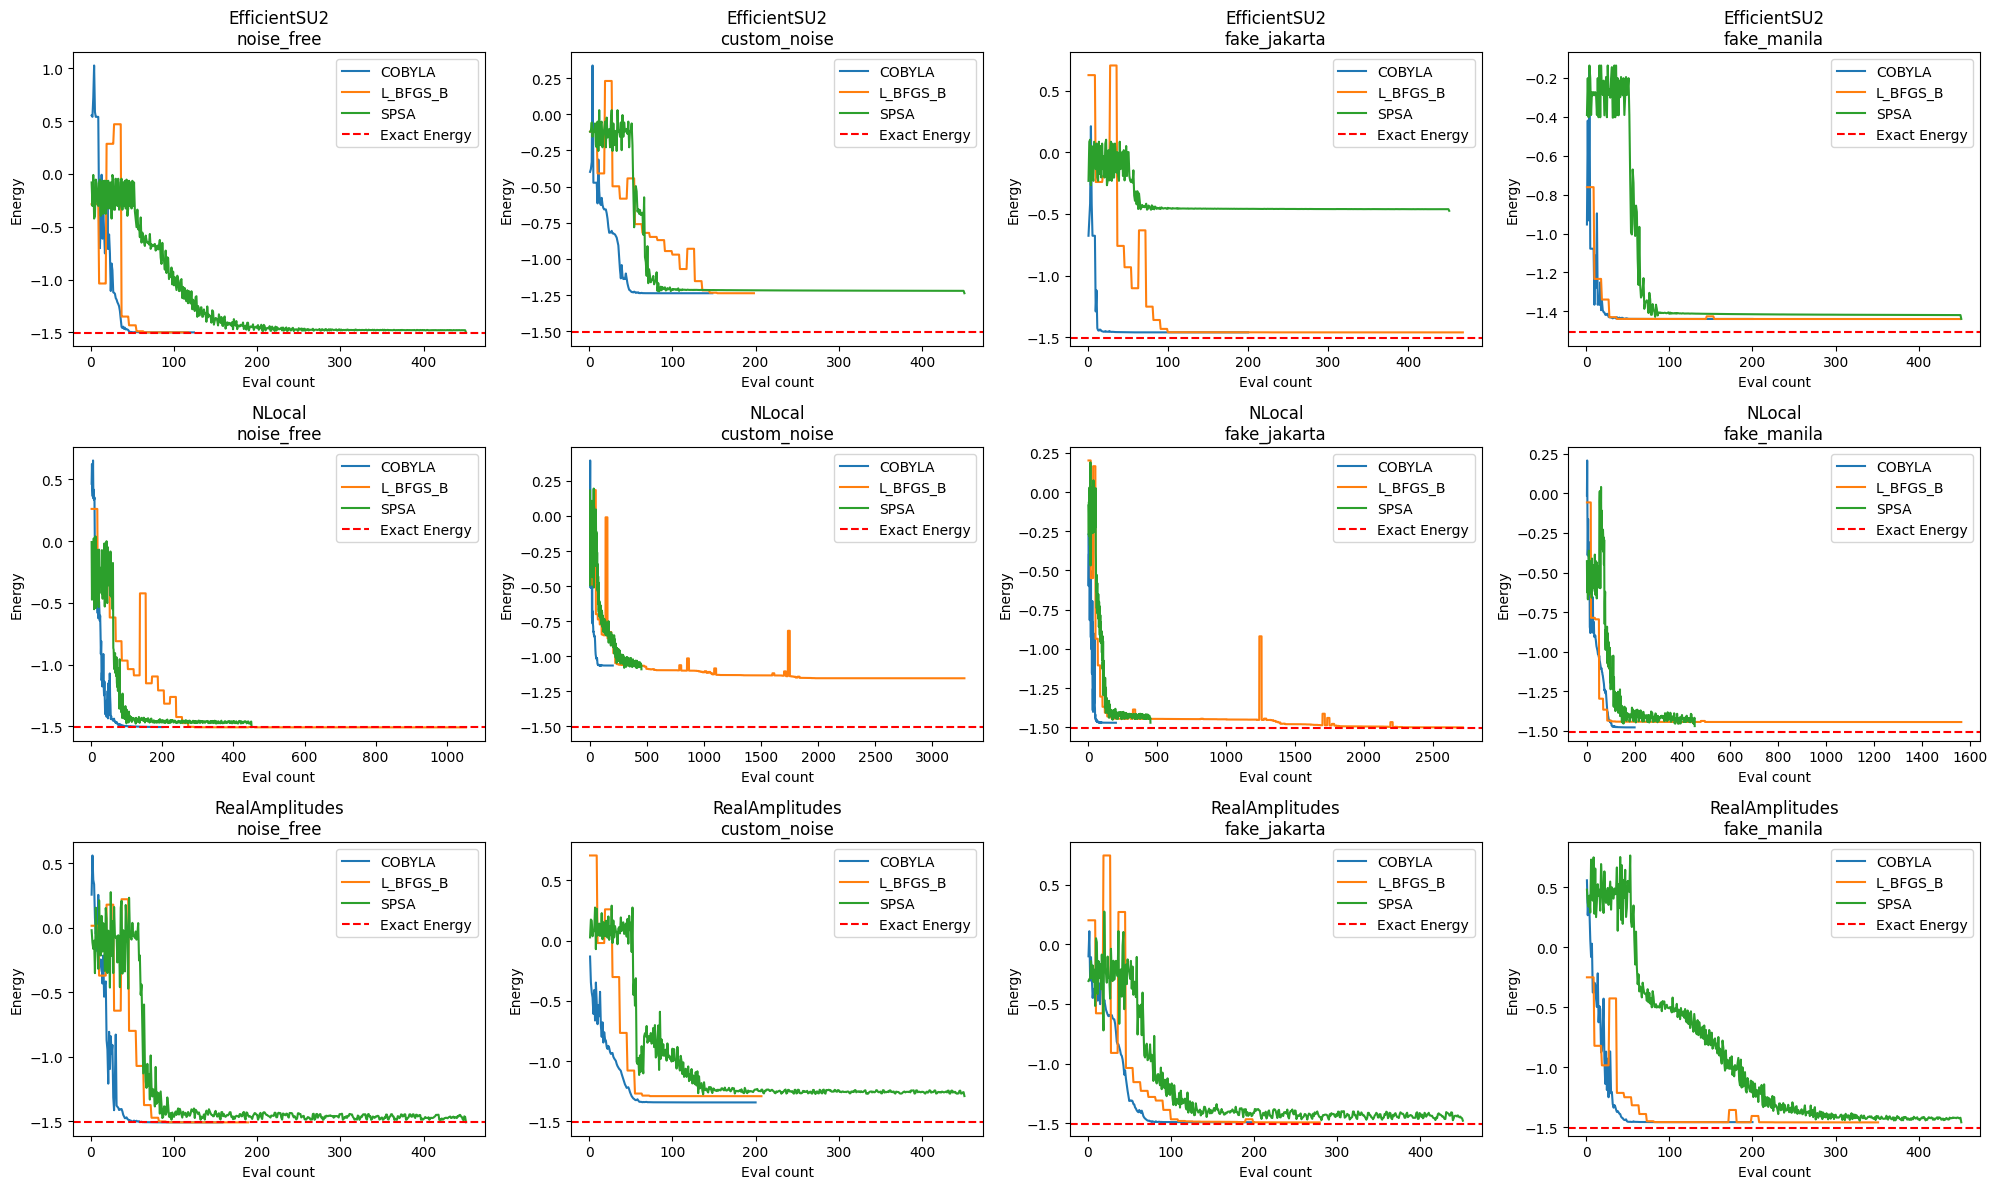

In [214]:
ansatz_names = list(ansatz_list.keys())
sim_names = list(simulators.keys())

fig, axes = plt.subplots(3, 4, figsize=(20,12))

for i, ansatz_name in enumerate(ansatz_names):
    for j, sim_name in enumerate(sim_names):

        ax = axes[i, j]

        for optimizer in optimizers:

            opt_name = type(optimizer).__name__

            data = convergence_data[ansatz_name][sim_name][opt_name]

            ax.plot(
                data["counts"],
                data["values"],
                label=opt_name
            )
        ax.axhline(gs_energy, linestyle="--", color="red", label="Exact Energy")
        ax.set_title(f"{ansatz_name}\n{sim_name}")
        ax.set_xlabel("Eval count")
        ax.set_ylabel("Energy")
        ax.legend()

plt.tight_layout()
plt.show()

In [208]:
!pip install rich -q

In [213]:
from rich.table import Table
from rich.console import Console
import pandas as pd

console = Console()

# Convert results list to dataframe
df = pd.DataFrame(results)
# pick the row with minimum ΔE Error for each Ansatz + Simulator pair
best_df = df.loc[
    df.groupby(["Ansatz", "Estimator"])["ΔE Error"].idxmin()
].sort_values(["Ansatz", "Estimator"])

console = Console()

table = Table(title="Best VQE Configuration per Ansatz & Simulator")

table.add_column("Ansatz", style="cyan", no_wrap=True)
table.add_column("Estimator", style="magenta")
table.add_column("Best Optimizer", style="green")
table.add_column("Final Energy", justify="right")
table.add_column("ΔE Error", justify="right")
table.add_column("Time (s)", justify="right")

for _, row in best_df.iterrows():
    table.add_row(
        row["Ansatz"],
        row["Estimator"],
        row["Optimizer"],
        f"{row['Final Energy']:.8f}",
        f"{row['ΔE Error']:.8f}",
        f"{row['Time (s)']:.3f}"
    )

console.print(table)

                      Best VQE Configuration per Ansatz & Simulator                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Ansatz         ┃ Estimator    ┃ Best Optimizer ┃ Final Energy ┃   ΔE Error ┃ Time (s) ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ EfficientSU2   │ custom_noise │ SPSA           │  -1.23693660 │ 0.27061917 │    0.246 │
│ EfficientSU2   │ fake_jakarta │ L_BFGS_B       │  -1.46055682 │ 0.04699894 │    9.503 │
│ EfficientSU2   │ fake_manila  │ L_BFGS_B       │  -1.43902469 │ 0.06853107 │    9.459 │
│ EfficientSU2   │ noise_free   │ L_BFGS_B       │  -1.50000000 │ 0.00755576 │    0.094 │
│ NLocal         │ custom_noise │ L_BFGS_B       │  -1.15739692 │ 0.35015884 │    3.875 │
│ NLocal         │ fake_jakarta │ L_BFGS_B       │  -1.50117490 │ 0.00638086 │   66.611 │
│ NLocal         │ fake_manila  │ COBYLA         │  -1.47822526 │ 0.02933050 │    4.992 │
│ NLocal         │ noise_free   │ L_BFGS_B       │  -1.50750161 │ 0.00005415 │    0.969 │
│ RealAmplitudes │ custom_noise │ COBYLA         │  -1.34192556 │ 0.16563020 │    0.284 │
│ RealAmplitudes │ fake_jakarta │ L_BFGS_B       │  -1.49232135 │ 0.01523441 │    8.186 │
│ RealAmplitudes │ fake_manila  │ L_BFGS_B       │  -1.45867714 │ 0.04887862 │   10.219 │
│ RealAmplitudes │ noise_free   │ COBYLA         │  -1.50750620 │ 0.00004956 │    0.259 │
└────────────────┴──────────────┴────────────────┴──────────────┴────────────┴──────────┘

<a id="vqe-strengths-weaknesses"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">
Strengths and Weaknesses of the Variational Quantum Eigensolver (VQE)
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
font-size:17px;
">

<p>
The <b>Variational Quantum Eigensolver (VQE)</b> is one of the most widely studied
hybrid quantum–classical algorithms designed for near-term quantum devices.
It combines a parameterized quantum circuit with a classical optimization
routine to approximate the ground state energy of a Hamiltonian.
</p>

<p>
While VQE has many advantages for current noisy quantum hardware,
it also comes with several practical limitations. Below we summarize
the key strengths and weaknesses of the algorithm.
</p>

<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h4 style="color:red; font-weight:bold">Strengths of VQE</h4>

<ul>

<li>
<b>Suitability for near-term hardware:</b>
Many quantum algorithms require extremely low error rates and large-scale
fault-tolerant quantum computers. VQE, however, can be implemented on
current <i>Noisy Intermediate-Scale Quantum (NISQ)</i> devices because it
uses shallow circuits and hybrid optimization.
</li>

<li>
<b>Relatively shallow circuits:</b>
VQE often employs circuits with modest depth. This makes the algorithm
less sensitive to accumulated gate errors and allows it to benefit
from modern error mitigation techniques.
</li>

<li>
<b>Versatility:</b>
In principle, VQE can be applied to any problem that can be formulated
as an eigenvalue problem. This includes applications in
quantum chemistry, condensed matter physics, and combinatorial
optimization.
</li>

</ul>

<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h4 style="color:red; font-weight:bold">Weaknesses and Challenges of VQE</h4>

<ul>

<li>
<b>Heuristic nature:</b>
VQE does not guarantee convergence to the true ground state energy.
Its performance depends heavily on the choice of ansatz and the
classical optimizer. A poorly chosen ansatz may not contain the
required entanglement to represent the true ground state.
</li>

<li>
<b>Large number of parameters:</b>
Highly expressive ansatz circuits may contain many variational
parameters. This increases the complexity of the classical optimization
and may significantly slow down convergence.
</li>

<li>
<b>High measurement overhead:</b>
The expectation value of the Hamiltonian must be estimated by measuring
each Pauli term. Since many of these terms do not commute, they must
be measured separately, which increases the number of required
measurements for large systems.
</li>

<li>
<b>Effects of noise:</b>
Noise in quantum hardware can distort energy estimates during
optimization. This may lead the classical optimizer away from the
true minimum or slow down the convergence process.
Modern approaches such as <i>error mitigation</i> and
<i>error suppression</i> techniques are often used to alleviate this issue.
</li>

<li>
<b>Barren plateaus:</b>
Certain parameterized quantum circuits may contain regions of
extremely small gradients, known as <i>barren plateaus</i>.
In these regions, optimization becomes very difficult because
parameter updates produce almost no change in the measured energy.
Noise can further worsen this problem.
</li>

</ul>

</div>

In [1]:
import sys, qiskit, qiskit_aer, qiskit_nature, qiskit_algorithms, qiskit_ibm_runtime

print("Python:", sys.version)
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Nature:", qiskit_nature.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)

Python: 3.11.8 (main, Jan 11 2026, 14:26:18) [Clang 17.0.0 (clang-1700.0.13.5)]
Qiskit: 2.5.1
Qiskit Aer: 0.17.2
Qiskit Nature: 0.7.2
Qiskit Algorithms: 0.4.0
Qiskit IBM Runtime: 0.48.0
